In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading all 5 required datasets
orders = pd.read_csv(r'C:\Users\akash kashyap\Data Analysis\Final Project for resume\Funnel Analysis project\Dataset\olist_orders_dataset.csv')
payments = pd.read_csv(r'C:\Users\akash kashyap\Data Analysis\Final Project for resume\Funnel Analysis project\Dataset\olist_order_payments_dataset.csv')
reviews = pd.read_csv(r'C:\Users\akash kashyap\Data Analysis\Final Project for resume\Funnel Analysis project\Dataset\olist_order_reviews_dataset.csv')
items = pd.read_csv(r'C:\Users\akash kashyap\Data Analysis\Final Project for resume\Funnel Analysis project\Dataset\olist_order_items_dataset.csv')
customers = pd.read_csv(r'C:\Users\akash kashyap\Data Analysis\Final Project for resume\Funnel Analysis project\Dataset\olist_customers_dataset.csv')

print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Payments: (103886, 5)
Reviews: (99224, 7)
Items: (112650, 7)
Customers: (99441, 5)


In [4]:
# Orders dataset ka overview
print("=== ORDERS ===")
print(orders.dtypes)
print("\nNull values:")
print(orders.isnull().sum())

=== ORDERS ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Null values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [5]:
# Convert all date columns to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print(orders.dtypes)

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [6]:
# Order status count karo
status_counts = orders['order_status'].value_counts()
print(status_counts)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
# Funnel stages define karo
funnel_data = {
    'Stage': [
        'Orders Placed',
        'Orders Approved', 
        'Shipped to Carrier',
        'Delivered to Customer'
    ],
    'Count': [
        len(orders),
        orders['order_approved_at'].notna().sum(),
        orders['order_delivered_carrier_date'].notna().sum(),
        orders['order_delivered_customer_date'].notna().sum()
    ]
}

funnel_df = pd.DataFrame(funnel_data)
print(funnel_df)

                   Stage  Count
0          Orders Placed  99441
1        Orders Approved  99281
2     Shipped to Carrier  97658
3  Delivered to Customer  96476


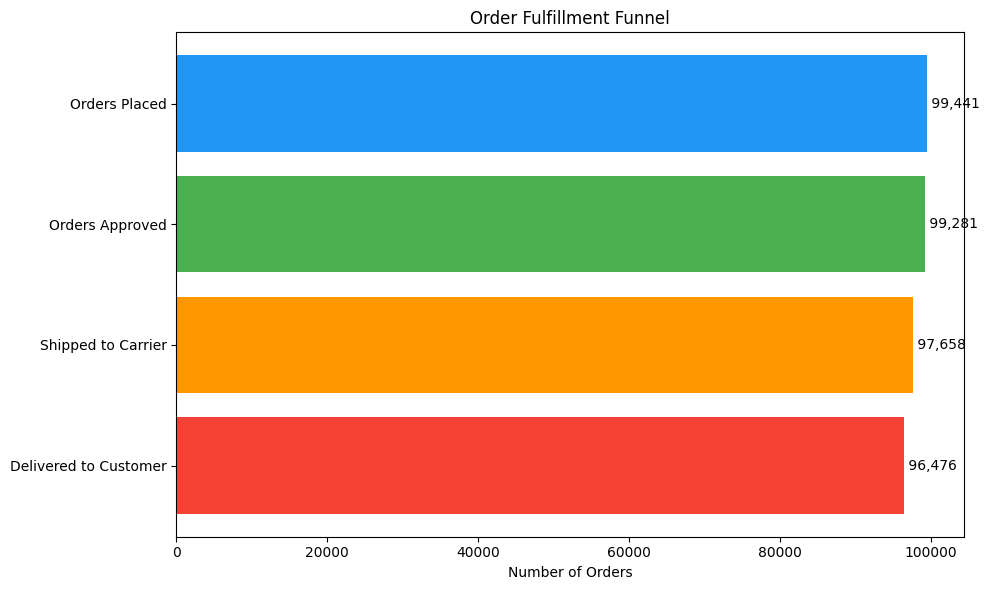

In [8]:
# Funnel bar chart
plt.figure(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

plt.barh(funnel_df['Stage'], funnel_df['Count'], color=colors)
plt.xlabel('Number of Orders')
plt.title('Order Fulfillment Funnel')

# Har bar pe number dikhao
for index, value in enumerate(funnel_df['Count']):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

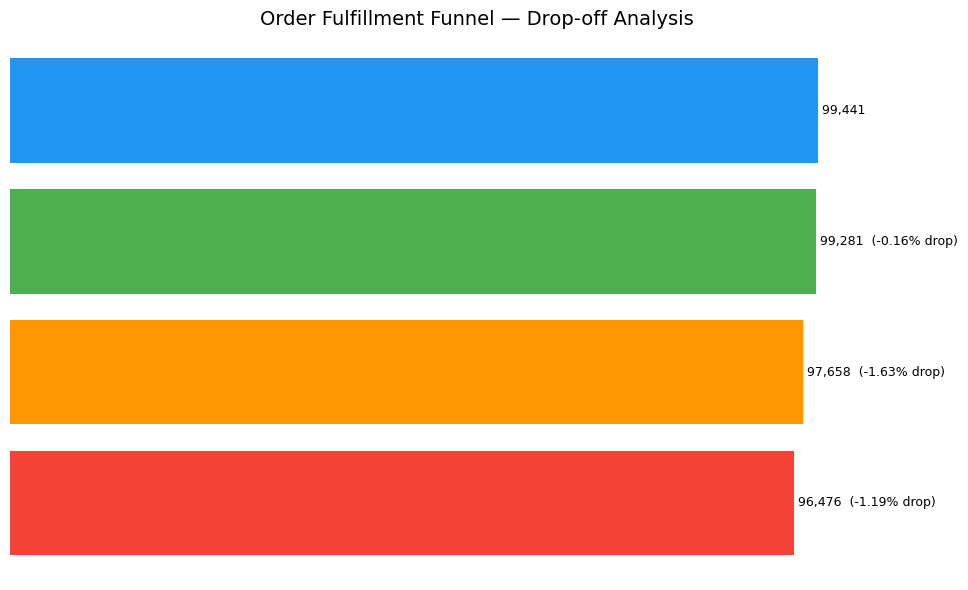

In [9]:
# Drop-off percentage ke saath funnel
funnel_df['Drop_off'] = funnel_df['Count'].shift(1) - funnel_df['Count']
funnel_df['Drop_pct'] = (funnel_df['Drop_off'] / funnel_df['Count'].iloc[0] * 100).round(2)

plt.figure(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

bars = plt.barh(funnel_df['Stage'], funnel_df['Count'], color=colors)
plt.title('Order Fulfillment Funnel — Drop-off Analysis', fontsize=14)

# Count aur drop % dono dikhao
for index, row in funnel_df.iterrows():
    label = f"{row['Count']:,}"
    if index > 0:
        label += f"  (-{row['Drop_pct']}% drop)"
    plt.text(row['Count'], index, f' {label}', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.xlim(0, 115000)
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# On-time vs Late delivery calculate karo
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date'] > 
    delivered_orders['order_estimated_delivery_date']
)

late_count = delivered_orders['is_late'].sum()
ontime_count = (~delivered_orders['is_late']).sum()
total_delivered = len(delivered_orders)

print(f"Total Delivered: {total_delivered:,}")
print(f"On Time: {ontime_count:,} ({ontime_count/total_delivered*100:.2f}%)")
print(f"Late: {late_count:,} ({late_count/total_delivered*100:.2f}%)")

Total Delivered: 96,478
On Time: 88,652 (91.89%)
Late: 7,826 (8.11%)


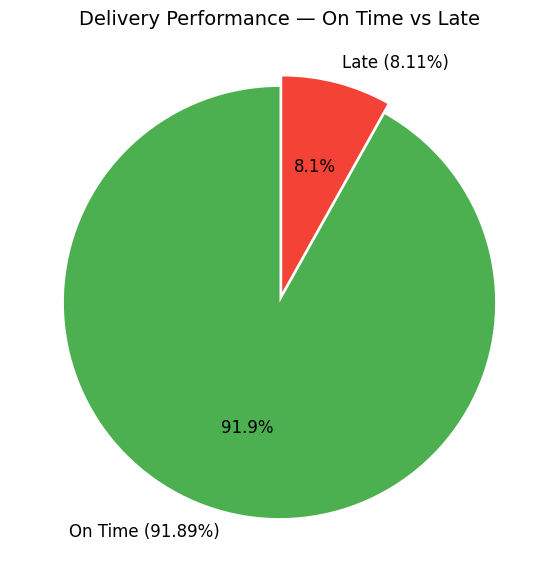

In [11]:
# On-time vs Late pie chart
plt.figure(figsize=(7, 7))
labels = ['On Time (91.89%)', 'Late (8.11%)']
sizes = [ontime_count, late_count]
colors = ['#4CAF50', '#F44336']
explode = (0, 0.05)

plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Delivery Performance — On Time vs Late', fontsize=14)
plt.show()

In [12]:
# Payments dataset merge karo orders ke saath
orders_payments = orders.merge(payments, on='order_id', how='left')

# Total revenue
total_revenue = orders_payments['payment_value'].sum()
avg_order_value = orders_payments.groupby('order_id')['payment_value'].sum().mean()

print(f"Total Revenue: R${total_revenue:,.2f}")
print(f"Average Order Value: R${avg_order_value:,.2f}")
print(f"\nPayment Type Distribution:")
print(orders_payments['payment_type'].value_counts())

Total Revenue: R$16,008,872.12
Average Order Value: R$160.99

Payment Type Distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


C:\Users\akash kashyap\AppData\Local\Temp\ipykernel_17516\4071868862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Blues_d')


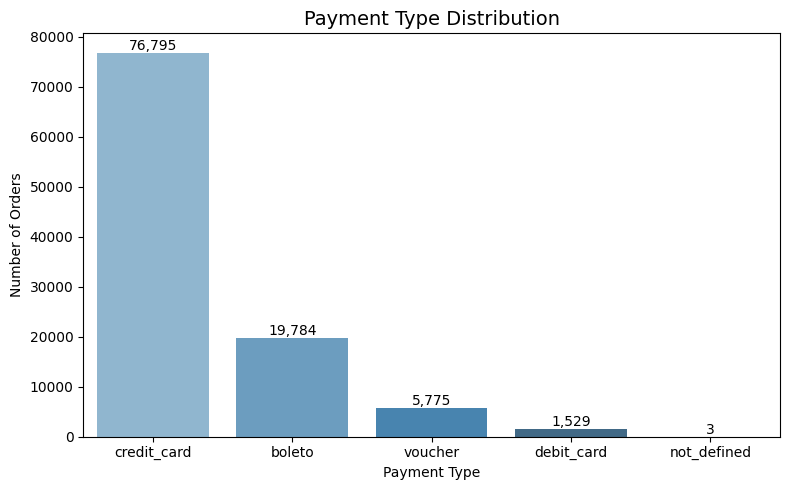

In [14]:
# Payment type bar chart
plt.figure(figsize=(8, 5))
payment_counts = orders_payments['payment_type'].value_counts()

sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Blues_d')
plt.title('Payment Type Distribution', fontsize=14)
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')

for i, v in enumerate(payment_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
orders_reviews = orders.merge(reviews, on='order_id', how='left')

print("Review Score Distribution:")
print(orders_reviews['review_score'].value_counts().sort_index())
print(f"\nAverage Review Score: {orders_reviews['review_score'].mean():.2f}")

Review Score Distribution:
review_score
1.0    11424
2.0     3151
3.0     8179
4.0    19142
5.0    57328
Name: count, dtype: int64

Average Review Score: 4.09


In [16]:
# Late delivery ka review score pe impact
orders_delivery_review = delivered_orders.merge(reviews, on='order_id', how='left')

late_reviews = orders_delivery_review[orders_delivery_review['is_late'] == True]['review_score'].mean()
ontime_reviews = orders_delivery_review[orders_delivery_review['is_late'] == False]['review_score'].mean()

print(f"Late Delivery Avg Review Score:    {late_reviews:.2f}")
print(f"On-Time Delivery Avg Review Score: {ontime_reviews:.2f}")

Late Delivery Avg Review Score:    2.57
On-Time Delivery Avg Review Score: 4.29


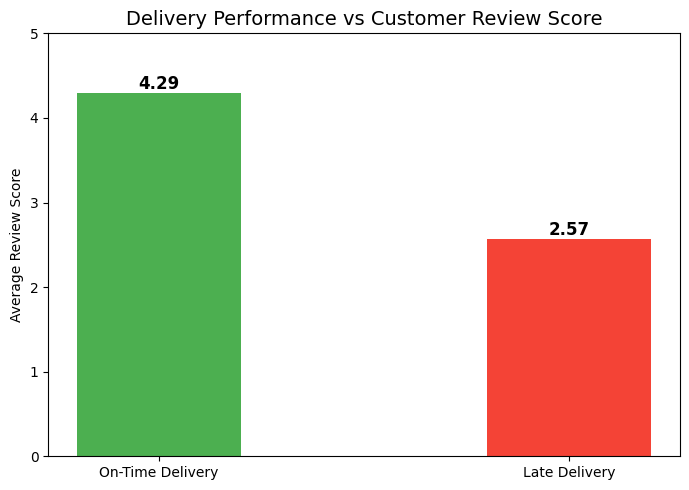

In [17]:
# Late vs On-time review comparison
plt.figure(figsize=(7, 5))
categories = ['On-Time Delivery', 'Late Delivery']
scores = [ontime_reviews, late_reviews]
colors = ['#4CAF50', '#F44336']

bars = plt.bar(categories, scores, color=colors, width=0.4)
plt.title('Delivery Performance vs Customer Review Score', fontsize=14)
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{score:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# OLIST E-COMMERCE FUNNEL ANALYSIS — KEY INSIGHTS SUMMARY
# ============================================================

print("=" * 60)
print("OLIST E-COMMERCE FUNNEL ANALYSIS — KEY INSIGHTS")
print("=" * 60)

print(f"""
DATASET OVERVIEW:
- Total Orders: 99,441
- Total Revenue: R$16,008,872.12
- Average Order Value: R$160.99
- Time Period: 2016 - 2018

FUNNEL DROP-OFF ANALYSIS:
- Orders Placed:          99,441
- Orders Approved:        99,281  (-0.16% drop)
- Shipped to Carrier:     97,658  (-1.63% drop) ← Highest Drop
- Delivered to Customer:  96,476  (-2.97% cumulative drop)

DELIVERY PERFORMANCE:
- On-Time Deliveries: 88,652 (91.89%)
- Late Deliveries:     7,826  (8.11%)

PAYMENT INSIGHTS:
- Most Popular: Credit Card — 76,795 orders (74.5%)
- Second: Boleto — 19,784 orders
- Total Revenue: R$16,008,872.12

CUSTOMER SATISFACTION:
- Average Review Score: 4.09 / 5
- On-Time Delivery Avg Score: 4.29
- Late Delivery Avg Score:    2.57
- 1-Star Reviews: 11,424 customers

KEY FINDINGS:
1. Highest funnel drop-off at Shipped to Carrier stage
   — 1,623 orders lost due to last-mile delivery failure
2. 8.11% orders delivered late — carrier performance issue
3. Credit card dominates payments at 74.5% of all orders
4. Late delivery causes review score to drop from 4.29 to 2.57
5. 11,424 customers gave 1-star review — mostly late deliveries

BUSINESS RECOMMENDATIONS:
1. Improve last-mile delivery — audit carrier performance
2. Reduce late deliveries — set SLA with logistics partners
3. Offer compensation to late delivery customers
4. Focus on credit card payment experience — most popular
5. Proactively notify customers about delayed orders
""")
print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60) 

OLIST E-COMMERCE FUNNEL ANALYSIS — KEY INSIGHTS

DATASET OVERVIEW:
- Total Orders: 99,441
- Total Revenue: R$16,008,872.12
- Average Order Value: R$160.99
- Time Period: 2016 - 2018

FUNNEL DROP-OFF ANALYSIS:
- Orders Placed:          99,441
- Orders Approved:        99,281  (-0.16% drop)
- Shipped to Carrier:     97,658  (-1.63% drop) ← Highest Drop
- Delivered to Customer:  96,476  (-2.97% cumulative drop)

DELIVERY PERFORMANCE:
- On-Time Deliveries: 88,652 (91.89%)
- Late Deliveries:     7,826  (8.11%)

PAYMENT INSIGHTS:
- Most Popular: Credit Card — 76,795 orders (74.5%)
- Second: Boleto — 19,784 orders
- Total Revenue: R$16,008,872.12

CUSTOMER SATISFACTION:
- Average Review Score: 4.09 / 5
- On-Time Delivery Avg Score: 4.29
- Late Delivery Avg Score:    2.57
- 1-Star Reviews: 11,424 customers

KEY FINDINGS:
1. Highest funnel drop-off at Shipped to Carrier stage
   — 1,623 orders lost due to last-mile delivery failure
2. 8.11% orders delivered late — carrier performance issue
3. C